# 01 · Initial EDA

Reproduces every number and chart in the Sept 30 status deck.
Read-only: it only **reads** `data/processed/` and `data/manual/` and writes nothing.

Run from the repo root or from `notebooks/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# find the data folder whether we run from repo root or notebooks/
DATA = Path("data") if Path("data").exists() else Path("../data")

## 1. Load the data

In [2]:
seg   = pd.read_csv(DATA / "processed/ev_registrations_segment_monthly.csv", parse_dates=["month"])
state = pd.read_csv(DATA / "processed/ev_registrations_state_monthly.csv", parse_dates=["month"])
prod  = pd.read_csv(DATA / "processed/ev_production_model_monthly.csv", parse_dates=["month"])
ann   = pd.read_csv(DATA / "manual/investment_announcements.csv")

print(len(seg), len(state), len(prod), len(ann))

799 3216 1363 21


## 2. National EV registrations are growing fast

In [3]:
# total registrations per month (all segments added up)
national = seg.groupby("month")["ev_registrations"].sum()

print("First month:", national.iloc[0])
print("Peak month :", national.idxmax().date(), national.max())

First month: 9008
Peak month : 2026-07-01 332544


month
2018     131197
2019     167917
2020     126007
2021     341279
2022    1059660
2023    1581708
2024    2025425
2025    2356222
2026    2337504
Name: ev_registrations, dtype: int64
Growth 2018 -> 2025: 18.0 x


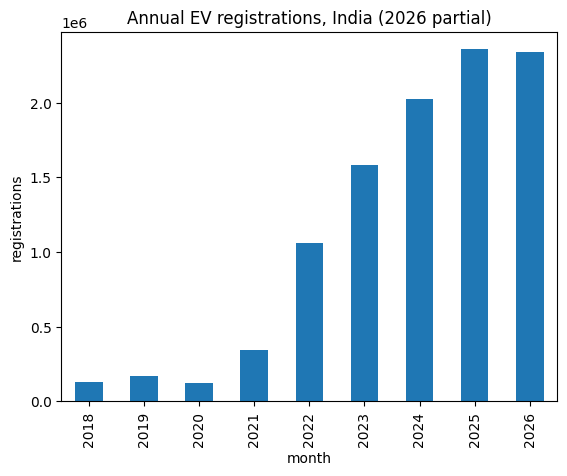

In [4]:
# total per year (2026 is a partial year)
yearly = seg.groupby(seg["month"].dt.year)["ev_registrations"].sum()
print(yearly)
print("Growth 2018 -> 2025:", round(yearly[2025] / yearly[2018], 1), "x")

yearly.plot(kind="bar", title="Annual EV registrations, India (2026 partial)")
plt.ylabel("registrations")
plt.show()

## 3. The market is mostly two- and three-wheelers

In [5]:
seg_2026 = seg[seg["month"].dt.year == 2026]
share = seg_2026.groupby("vehicle_segment")["ev_registrations"].sum()
share = (share / share.sum() * 100).round(1).sort_values(ascending=False)
share

vehicle_segment
2W                        62.1
3W                        26.8
4W                         9.6
LCV                        0.8
Small Buses                0.4
Buses                      0.2
M&HCV                      0.1
Construction Equipment     0.0
Tractors                   0.0
Name: ev_registrations, dtype: float64

## 4. Demand is concentrated by state (2026)

Top-5 share: 48.9 %
HHI: 0.071
state
Uttar Pradesh     14.2
Maharashtra       11.2
Karnataka          9.1
Tamil Nadu         8.6
Madhya Pradesh     5.8
Name: ev_total, dtype: float64


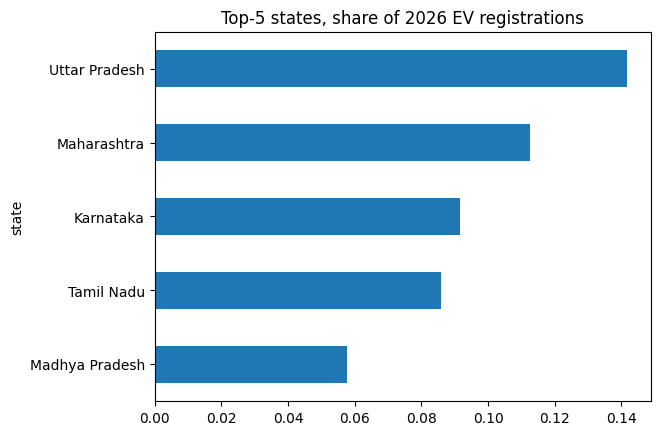

In [6]:
state_2026 = state[state["month"].dt.year == 2026]
state_share = state_2026.groupby("state")["ev_total"].sum()
state_share = state_share / state_share.sum()

top5 = state_share.sort_values(ascending=False).head(5)
hhi = (state_share ** 2).sum()   # Herfindahl index: 0 = spread out, 1 = one state has everything

print("Top-5 share:", round(top5.sum() * 100, 1), "%")
print("HHI:", round(hhi, 3))
print((top5 * 100).round(1))

top5.sort_values().plot(kind="barh", title="Top-5 states, share of 2026 EV registrations")
plt.show()

## 5. Production vs registrations

Production data ends 2026-07 — 2026-08 is incomplete (only 5 of 11 OEMs reported), so we drop it.

Usable production months: 40
Coverage first month: 18 %
Coverage last month : 60 %


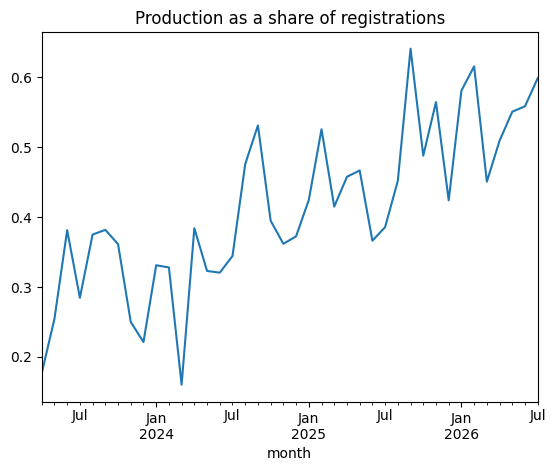

In [7]:
production = prod.groupby("month")["production_units"].sum()
production = production[production.index <= "2026-07-01"]
print("Usable production months:", len(production))

# what share of registrations the production feed covers
coverage = production / national.reindex(production.index)
print("Coverage first month:", round(coverage.iloc[0] * 100), "%")
print("Coverage last month :", round(coverage.iloc[-1] * 100), "%")

coverage.plot(title="Production as a share of registrations")
plt.show()

## 6. First lead–lag check

Month-on-month growth of both series. `k` = how many months production is shifted forward.
If production leads registrations, the correlation should be clearly positive at some k > 0.

In [8]:
growth = pd.DataFrame({
    "production": production.pct_change(),
    "registrations": national.reindex(production.index).pct_change(),
}).dropna()

print("n =", len(growth))
for k in range(0, 4):
    r = growth["production"].shift(k).corr(growth["registrations"])
    print("k =", k, " corr =", round(r, 2))

n = 39
k = 0  corr = 0.24
k = 1  corr = -0.2
k = 2  corr = 0.4
k = 3  corr = -0.29


Signs flip between k=0, 1, 2 — with n≈39 this looks like noise, not a real lead.

## 7. The dependent variable: investment announcements

In [9]:
print("Total events:", len(ann))
print(ann["date_precision"].value_counts())

# only events with an exact or month-level date can be used in a monthly test
dated = ann[ann["date_precision"].isin(["exact", "month"])].copy()
dated["month"] = dated["announcement_date"].str[:7]   # keep "YYYY-MM"

in_window = dated[(dated["month"] >= "2023-04") & (dated["month"] <= "2026-07")]
print("Dated events inside production window:", len(in_window))
print("Distinct months with an event:", in_window["month"].nunique())

Total events: 21
date_precision
fiscal_period    10
exact             8
month             3
Name: count, dtype: int64
Dated events inside production window: 8
Distinct months with an event: 7


## Summary

- Registrations grew ~18× from 2018 to 2025; 2W + 3W ≈ 89% of 2026 volume.
- Top-5 states ≈ 49% of 2026 registrations (HHI ≈ 0.07).
- Production feed covers a rising share of registrations (18% → 60%).
- Production/registration growth lead test is noisy at this sample size.
- Only a handful of dated announcement events fall in the window — the dependent variable is the main risk.